<a href="https://colab.research.google.com/github/silayuzer/Industrial-Defect-Detection-System-LSTMs/blob/main/ProjectData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
np.random.seed(42)

In [ ]:
n = 50000

In [ ]:
def createRow(n, classes):
    base = np.sin(np.linspace((np.random.rand(3)),(np.random.rand(3) + np.array([10,15,7])),n))
    if classes[0] > 0:
        base[np.random.randint(0,n), 0] += 2
    if classes[1] > 0:
        base[np.random.randint(0,n), 1] -= 2
    if classes[2] > 0:
        x = np.random.randint(0,n-5)
        base[x:x+4,2] = 0
    if classes[3] > 0:
        x = np.random.randint(0,n-10)
        base[x:x+8,1] += 1.5
    if classes[4] > 0:
        x = np.random.randint(0,n-7)
        base[x:x+6,0] += 1.5
        base[x:x+6,2] -= 1.5
    base += np.random.rand(*base.shape)*.2
    return base

In [ ]:
xl, yl = [], []
for _ in range(n):
    cl = np.random.rand(5)<.25
    xl.append(createRow(np.random.randint(40,60), cl))
    yl.append(cl)


[False False False False  True]


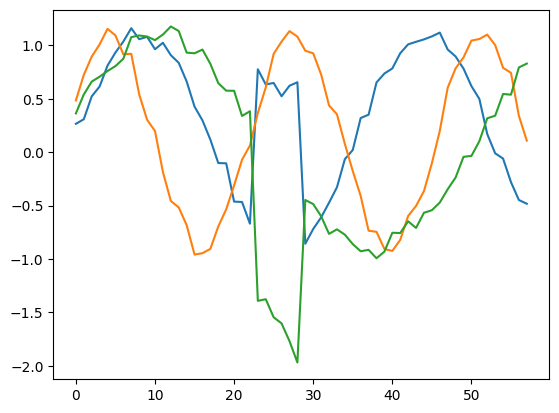

[False False False  True  True]


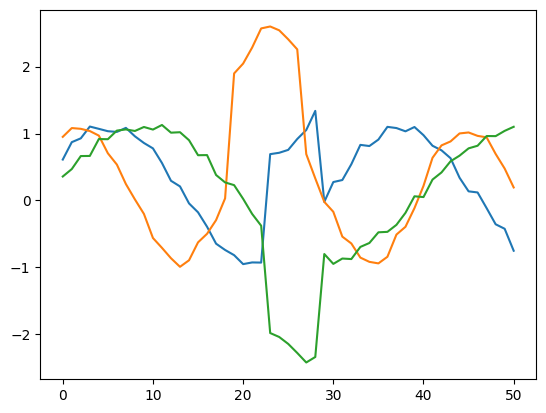

[False False False False False]


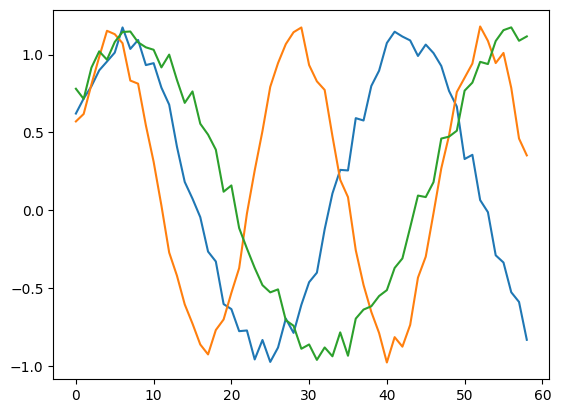

[ True False False False  True]


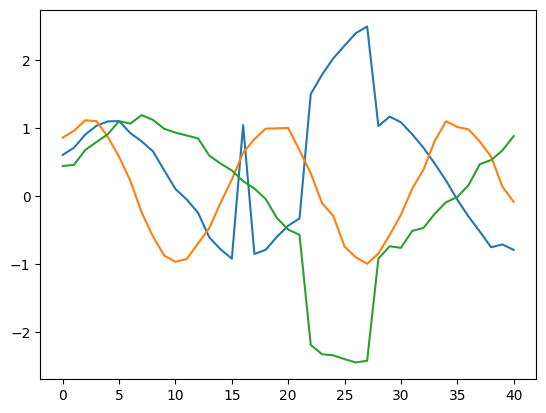

[False  True False False False]


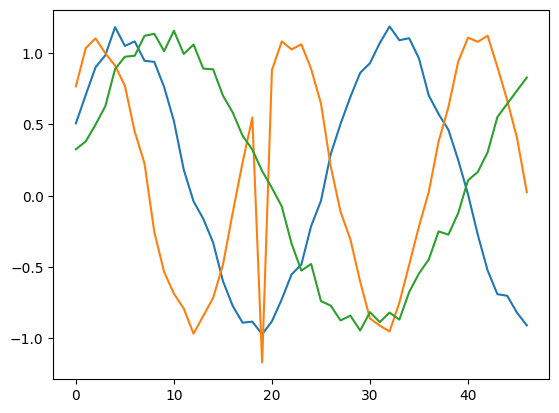

In [ ]:
for i in range(5):
    plt.plot(xl[i])
    print(yl[i])
    plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# 1. Pad all sequences with zeros according to the longest sequence (60)
X_padded = pad_sequences(xl, dtype='float32', padding='post', value=0.0)
Y = np.array(yl).astype(int)

# 2. Split the data into Train (64%), Validation (16%), and Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_padded, Y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)


In [ ]:
def build_pro_model(timesteps, features, num_classes):
    inputs = Input(shape=(timesteps, features))

    # Feature Embedding: Projects raw data into a 32-dimensional feature space
    embedded = TimeDistributed(Dense(32, activation='relu'))(inputs)

    # Encoder: Compresses the sequence into a single vector
    encoder = Bidirectional(LSTM(64, return_sequences=False))(embedded)
    encoder = Dropout(0.2)(encoder)

    # Decoder (Reconstruction): Tries to reconstruct the signal (for Root Cause Analysis)
    decoder_input = RepeatVector(timesteps)(encoder)
    decoder_output = Bidirectional(LSTM(64, return_sequences=True))(decoder_input)
    reconstruction = TimeDistributed(Dense(features), name='reconstruction')(decoder_output)

    # Classifier: Determines the defect type
    classifier = Dense(32, activation='relu')(encoder)
    classification = Dense(num_classes, activation='sigmoid', name='classification')(classifier)

    model = Model(inputs=inputs, outputs=[reconstruction, classification])

    # clipnorm is added to prevent gradient explosion [cite: 887-889]
    model.compile(
        optimizer=tf.keras.optimizers.Adam(clipnorm=1.0),
        loss={'reconstruction': 'mse', 'classification': 'binary_crossentropy'},
        loss_weights={'reconstruction': 0.5, 'classification': 1.0}
    )
    return model

model = build_pro_model(X_padded.shape[1], 3, 5)


In [ ]:
callbacks = [
    # 1. ModelCheckpoint: Saves the best model under the name 'best_candy_model.h5'.
    # Thanks to 'save_best_only=True', the file is updated only when val_loss improves.
    ModelCheckpoint(
        filepath='best_candy_model.h5',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),

    # 2. EarlyStopping: Stops training if the model does not improve for 7 epochs.
    # 'restore_best_weights=True' restores the model to its best weights at the end of training [cite: 831, 881].
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # 3. ReduceLROnPlateau: Reduces the learning rate when model improvement slows down.
    # This helps manage the gradient-related issues mentioned in the presentation.
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# The training command remains the same
history = model.fit(
    X_train,
    {'reconstruction': X_train, 'classification': y_train},
    validation_data=(X_val, {'reconstruction': X_val, 'classification': y_val}),
    epochs=50,
    batch_size=128,
    callbacks=callbacks
)


Epoch 1/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - classification_loss: 0.5145 - loss: 0.6567 - reconstruction_loss: 0.2843
Epoch 1: val_loss improved from inf to 0.33335, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - classification_loss: 0.5133 - loss: 0.6549 - reconstruction_loss: 0.2831 - val_classification_loss: 0.2866 - val_loss: 0.3333 - val_reconstruction_loss: 0.0931 - learning_rate: 0.0010
Epoch 2/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - classification_loss: 0.2805 - loss: 0.3285 - reconstruction_loss: 0.0959
Epoch 2: val_loss improved from 0.33335 to 0.25823, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - classification_loss: 0.2804 - loss: 0.3283 - reconstruction_loss: 0.0959 - val_classification_loss: 0.2192 - val_loss: 0.2582 - val_reconstruction_loss: 0.0779 - learning_rate: 0.0010
Epoch 3/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - classification_loss: 0.2259 - loss: 0.2675 - reconstruction_loss: 0.0831
Epoch 3: val_loss improved from 0.25823 to 0.23396, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - classification_loss: 0.2258 - loss: 0.2674 - reconstruction_loss: 0.0831 - val_classification_loss: 0.1954 - val_loss: 0.2340 - val_reconstruction_loss: 0.0770 - learning_rate: 0.0010
Epoch 4/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - classification_loss: 0.1977 - loss: 0.2366 - reconstruction_loss: 0.0779
Epoch 4: val_loss improved from 0.23396 to 0.18902, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.1976 - loss: 0.2365 - reconstruction_loss: 0.0779 - val_classification_loss: 0.1532 - val_loss: 0.1890 - val_reconstruction_loss: 0.0717 - learning_rate: 0.0010
Epoch 5/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - classification_loss: 0.1642 - loss: 0.2021 - reconstruction_loss: 0.0757
Epoch 5: val_loss improved from 0.18902 to 0.16025, saving model to best_candy_model.h5


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0036 - loss: 0.0204 - reconstruction_loss: 0.0337 - val_classification_loss: 0.0050 - val_loss: 0.0182 - val_reconstruction_loss: 0.0265 - learning_rate: 2.5000e-04
Epoch 41/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - classification_loss: 0.0040 - loss: 0.0209 - reconstruction_loss: 0.0337
Epoch 41: val_loss did not improve from 0.01823
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - classification_loss: 0.0040 - loss: 0.0209 - reconstruction_loss: 0.0337 - val_classification_loss: 0.0083 - val_loss: 0.0218 - val_reconstruction_loss: 0.0269 - learning_rate: 2.5000e-04
Epoch 42/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - classification_loss: 0.0054 - loss: 0.0220 - reconstruction_loss: 0.0332
Epoch 42: val_loss did not improve from 0.01823
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0054 - loss: 0.0220 - reconstruction_loss: 0.0332 - val_classification_loss: 0.0058 - val_loss: 0.0189 - val_recons

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0050 - loss: 0.0216 - reconstruction_loss: 0.0333 - val_classification_loss: 0.0050 - val_loss: 0.0178 - val_reconstruction_loss: 0.0257 - learning_rate: 2.5000e-04
Epoch 44/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - classification_loss: 0.0045 - loss: 0.0211 - reconstruction_loss: 0.0332
Epoch 44: val_loss did not improve from 0.01783
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - classification_loss: 0.0045 - loss: 0.0211 - reconstruction_loss: 0.0332 - val_classification_loss: 0.0050 - val_loss: 0.0180 - val_reconstruction_loss: 0.0259 - learning_rate: 2.5000e-04
Epoch 45/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - classification_loss: 0.0047 - loss: 0.0212 - reconstruction_loss: 0.0330
Epoch 45: val_loss did not improve from 0.01783
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0047 - loss: 0.0212 - reconstruction_loss: 0.0330 - val_classification_loss: 0.0086 - val_loss: 0.0215 - val_recons

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - classification_loss: 0.0037 - loss: 0.0197 - reconstruction_loss: 0.0321 - val_classification_loss: 0.0047 - val_loss: 0.0177 - val_reconstruction_loss: 0.0258 - learning_rate: 1.2500e-04
Epoch 48/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - classification_loss: 0.0032 - loss: 0.0194 - reconstruction_loss: 0.0323
Epoch 48: val_loss improved from 0.01766 to 0.01739, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0032 - loss: 0.0194 - reconstruction_loss: 0.0323 - val_classification_loss: 0.0048 - val_loss: 0.0174 - val_reconstruction_loss: 0.0251 - learning_rate: 1.2500e-04
Epoch 49/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - classification_loss: 0.0031 - loss: 0.0191 - reconstruction_loss: 0.0320
Epoch 49: val_loss did not improve from 0.01739
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - classification_loss: 0.0031 - loss: 0.0191 - reconstruction_loss: 0.0320 - val_classification_loss: 0.0050 - val_loss: 0.0175 - val_reconstruction_loss: 0.0250 - learning_rate: 1.2500e-04
Epoch 50/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - classification_loss: 0.0029 - loss: 0.0189 - reconstruction_loss: 0.0320
Epoch 50: val_loss improved from 0.01739 to 0.01722, saving model to best_candy_model.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - classification_loss: 0.0029 - loss: 0.0189 - reconstruction_loss: 0.0320 - val_classification_loss: 0.0048 - val_loss: 0.0172 - val_reconstruction_loss: 0.0248 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 50.


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2535
           1       1.00      1.00      1.00      2484
           2       1.00      0.98      0.99      2505
           3       1.00      1.00      1.00      2566
           4       1.00      1.00      1.00      2548

   micro avg       1.00      0.99      1.00     12638
   macro avg       1.00      0.99      1.00     12638
weighted avg       1.00      0.99      1.00     12638
 samples avg       0.77      0.77      0.77     12638

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


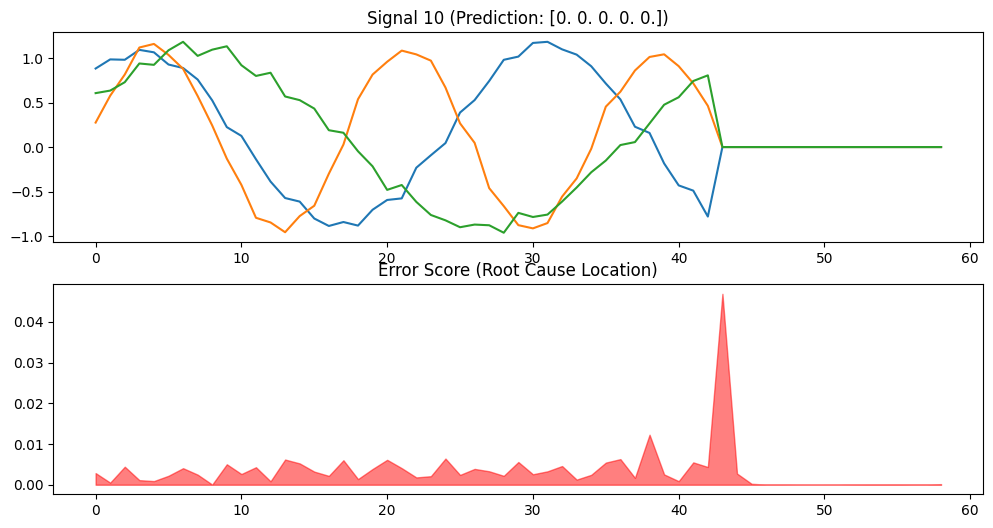

In [ ]:
from sklearn.metrics import classification_report

# Check classification performance
_, y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)  ## Threshold to assess a default or not
print(classification_report(y_test, y_pred))

# Root Cause Analysis Visualization
def visualize_results(idx):
    sample = X_test[idx:idx+1]
    recon, prob = model.predict(sample)
    error = np.mean(np.square(sample[0] - recon[0]), axis=1)  # Reconstruction error

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(sample[0]); plt.title(f"Signal {idx} (Prediction: {np.round(prob[0], 2)})")
    plt.subplot(2, 1, 2)
    plt.fill_between(range(len(error)), error, color='red', alpha=0.5)
    plt.title("Error Score (Root Cause Location)"); plt.show()

# Test on a random sample
visualize_results(10)


The Classification of the default done by the neural networks is very effecient almost 100% of the default are detected well.


Analyzing: Candy Index 6888
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


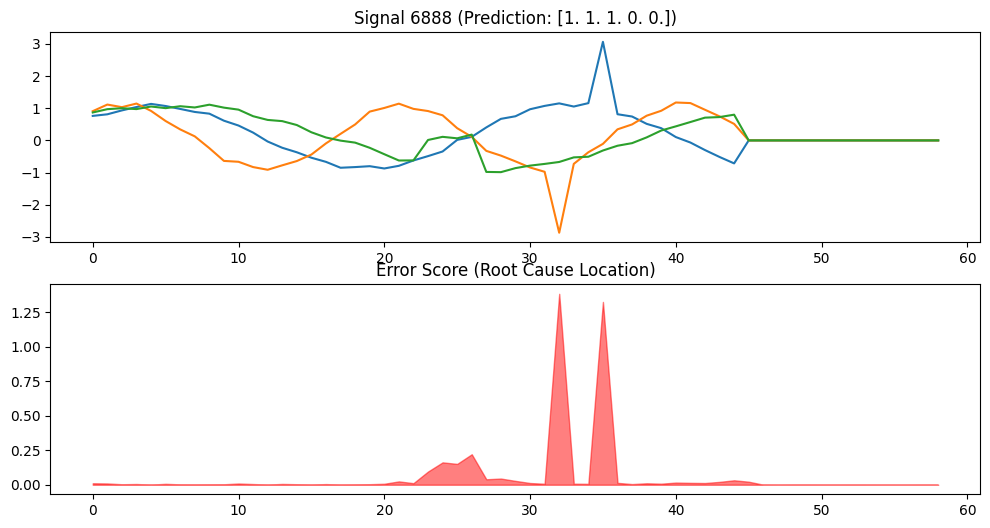


Analyzing: Candy Index 5869
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


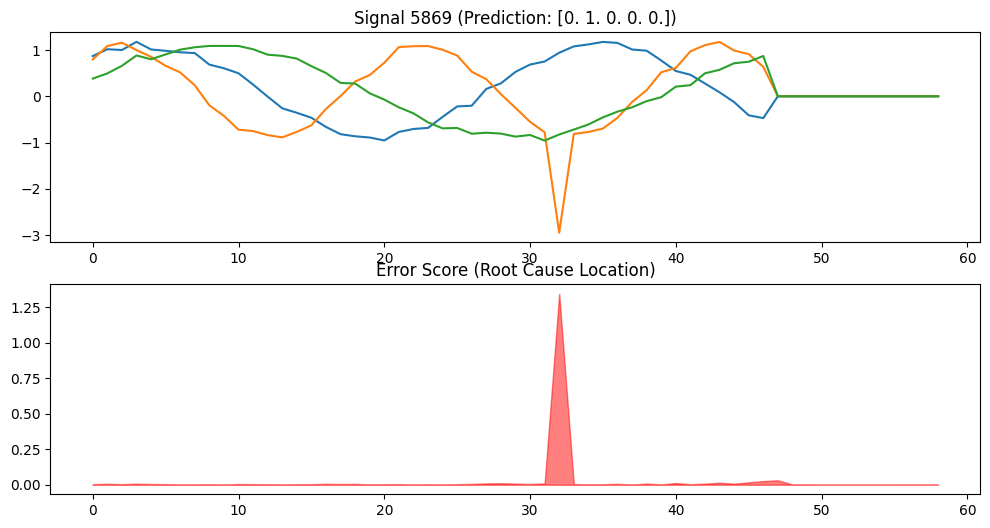


Analyzing: Candy Index 8817
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


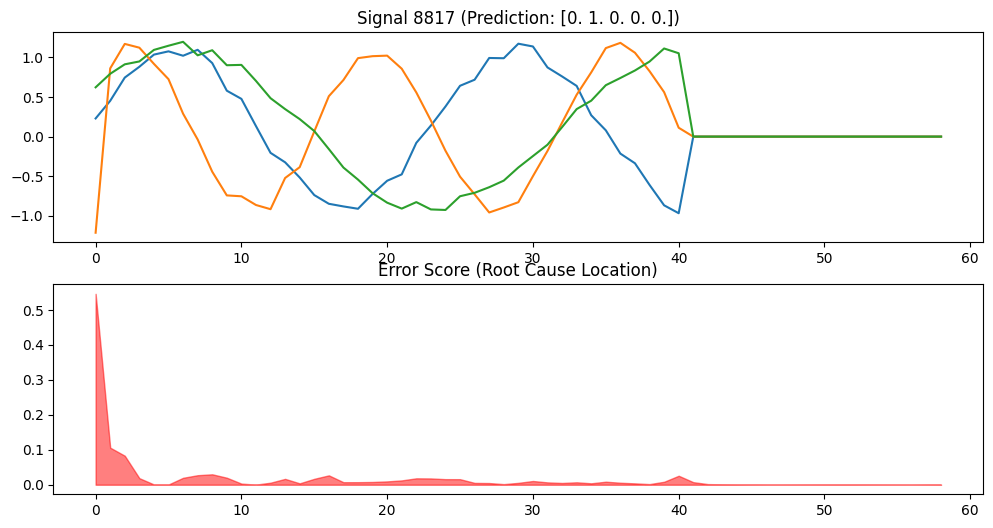


Analyzing: Candy Index 6403
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


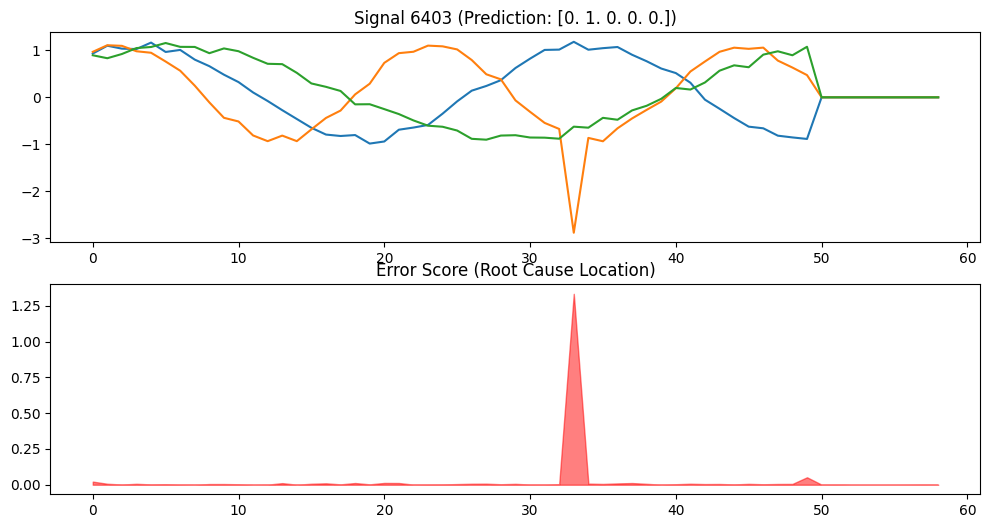


Analyzing: Candy Index 7727
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


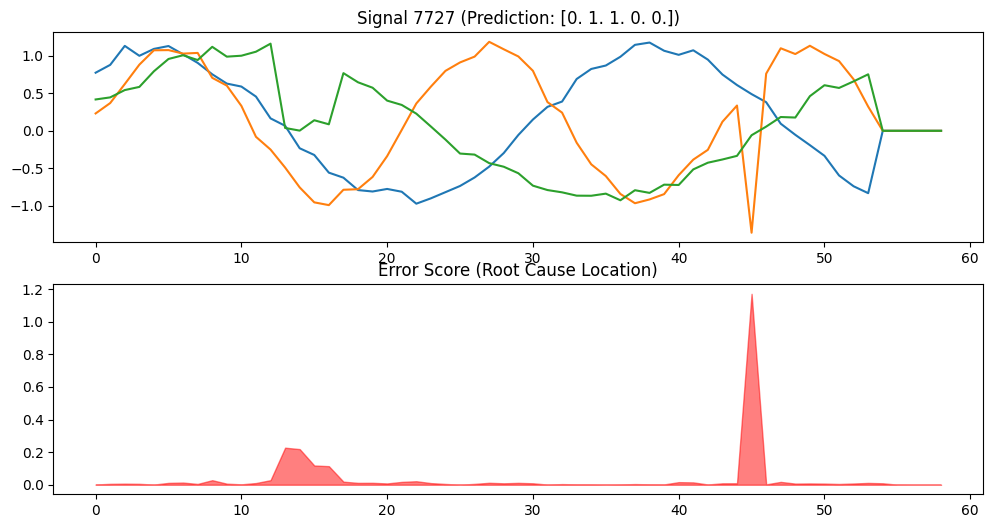


Analyzing: Candy Index 3485
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


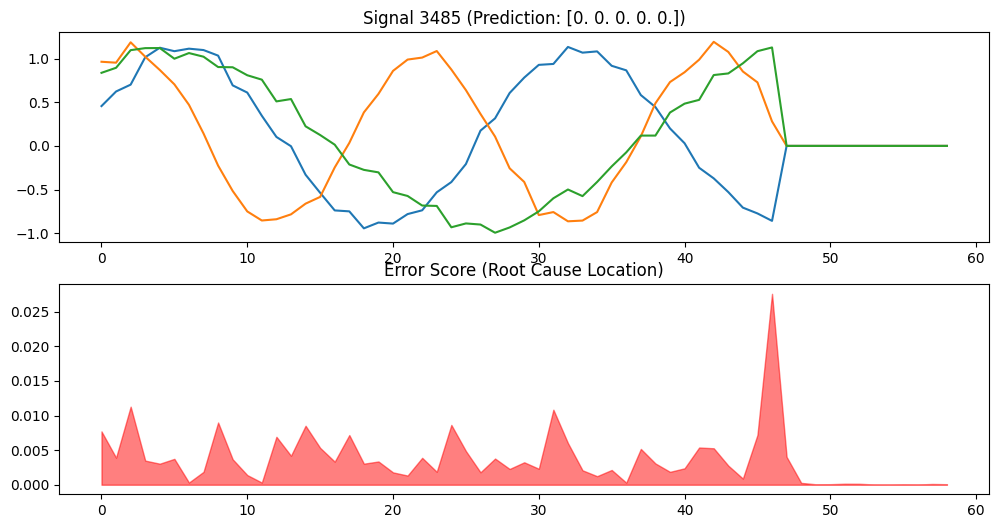


Analyzing: Candy Index 3574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


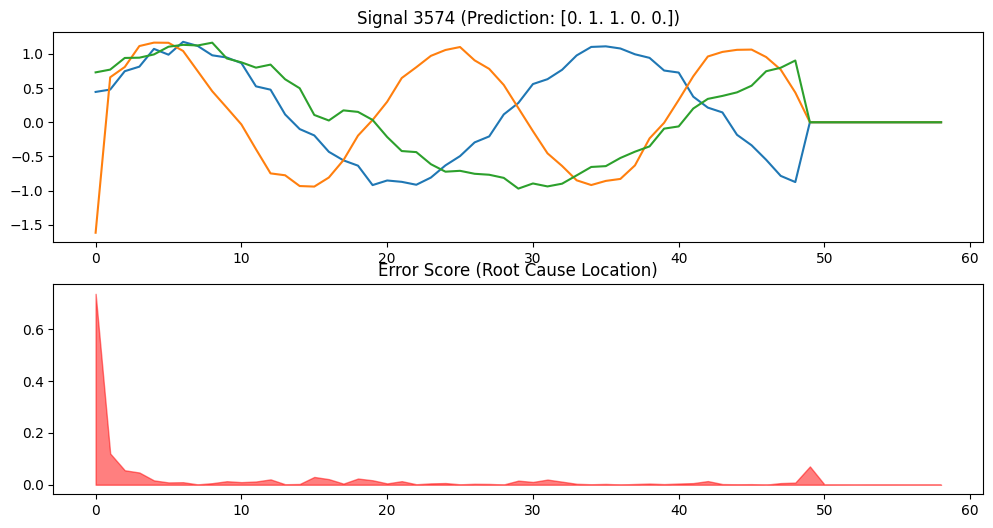


Analyzing: Candy Index 9067
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


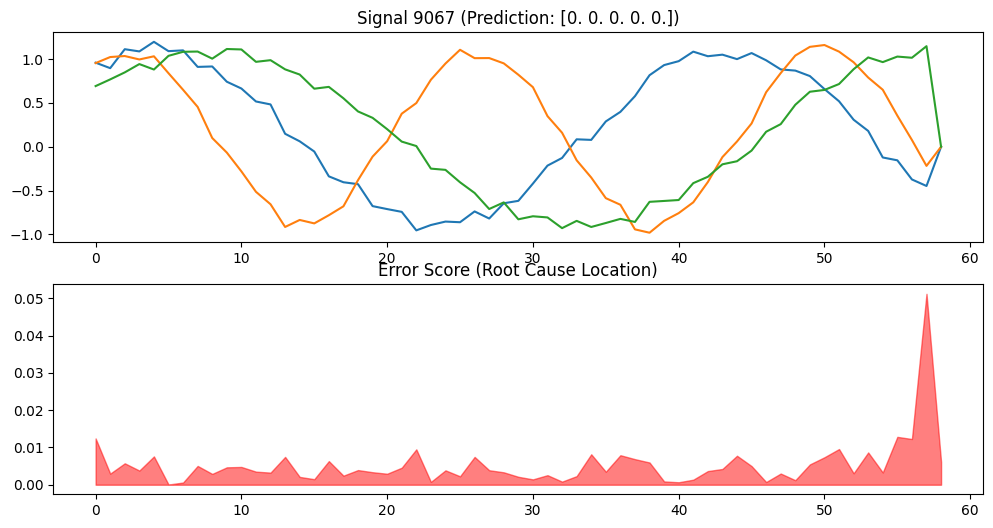


Analyzing: Candy Index 6085
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


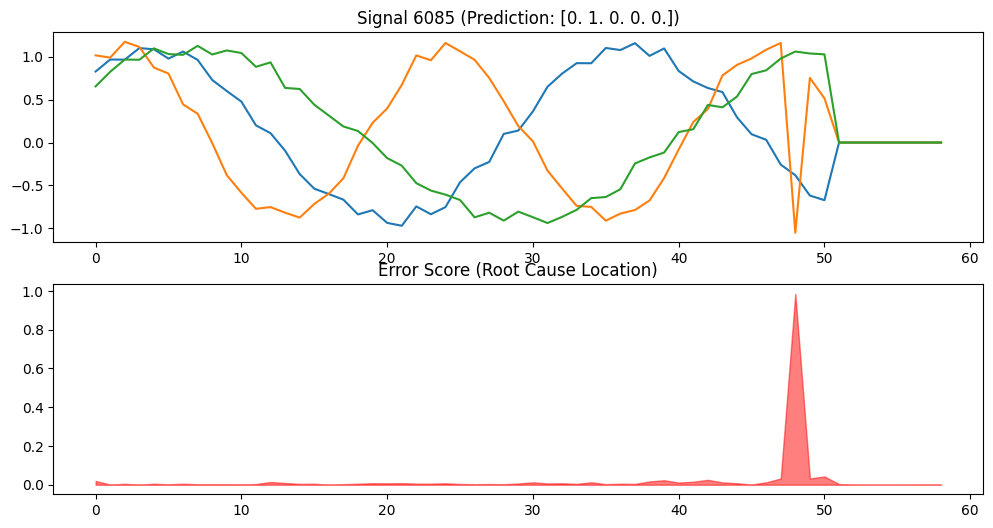


Analyzing: Candy Index 1162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


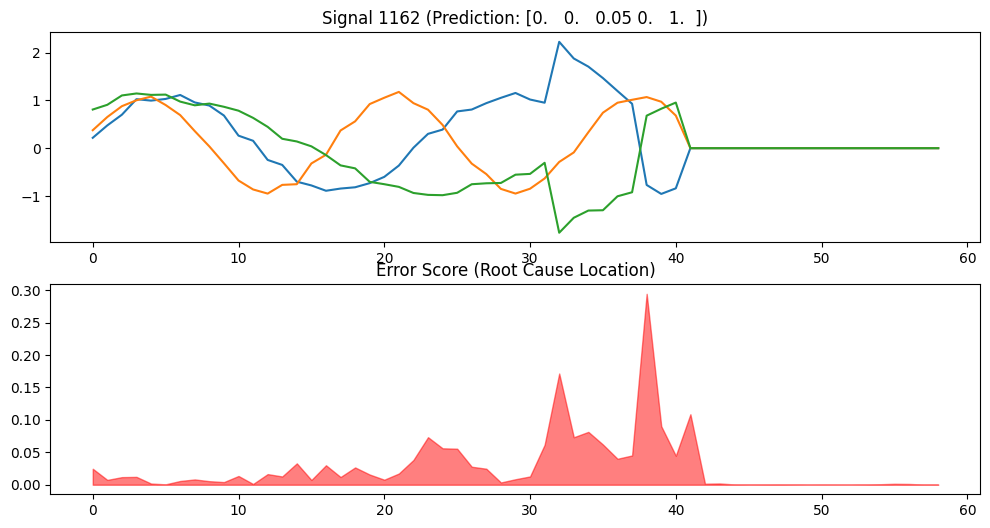


Analyzing: Candy Index 9996
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


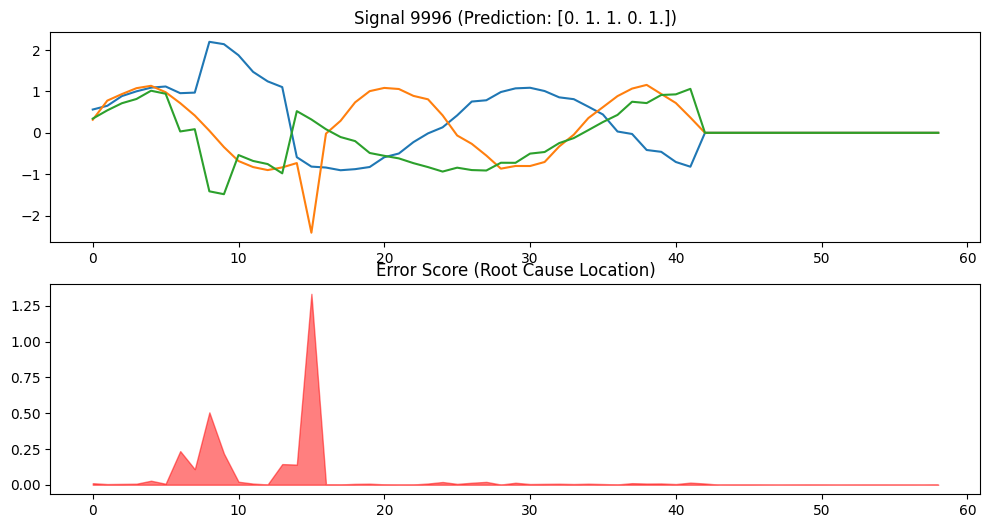


Analyzing: Candy Index 4186
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


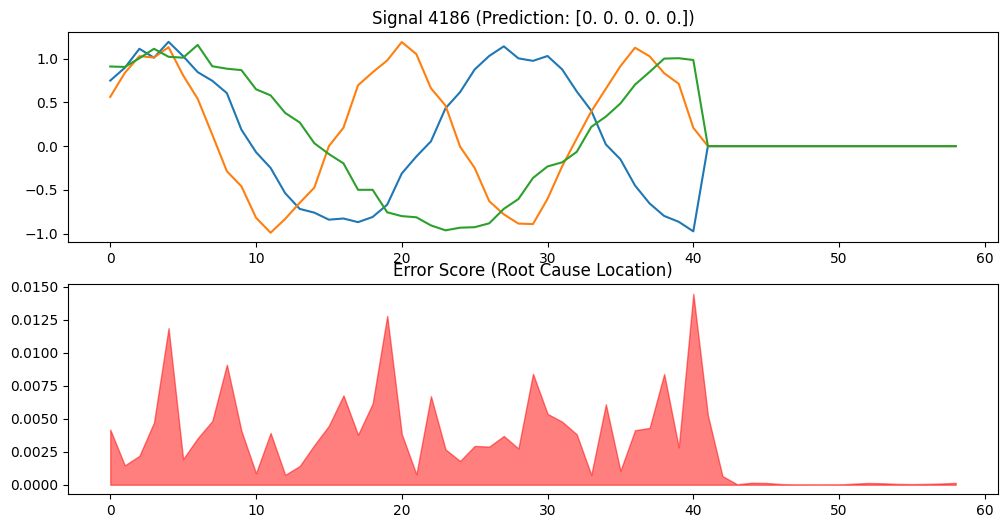


Analyzing: Candy Index 2944
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


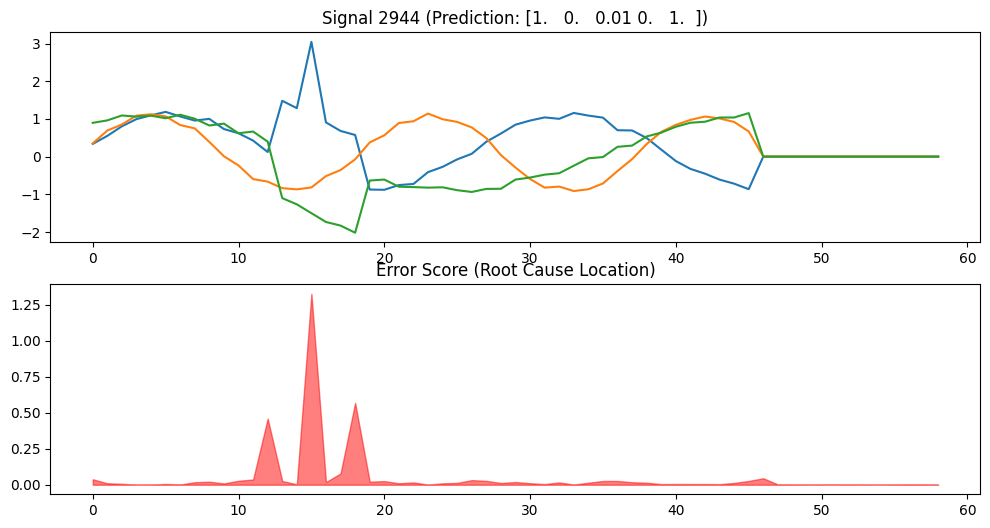


Analyzing: Candy Index 6597
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


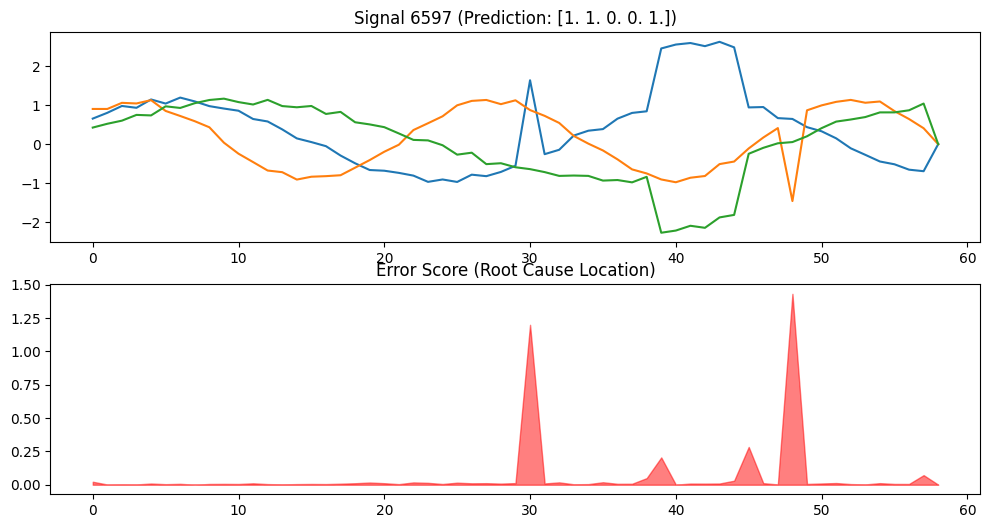


Analyzing: Candy Index 1314
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


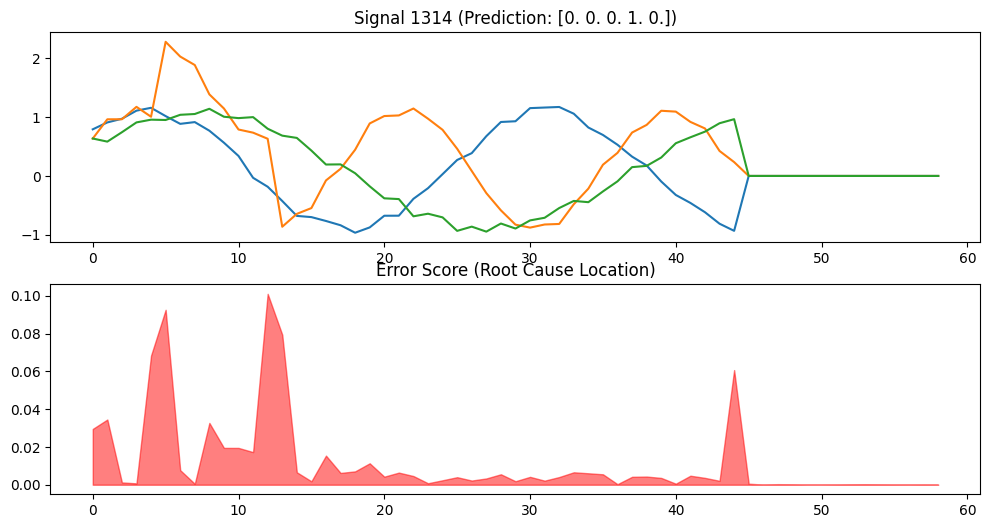


Analyzing: Candy Index 9652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


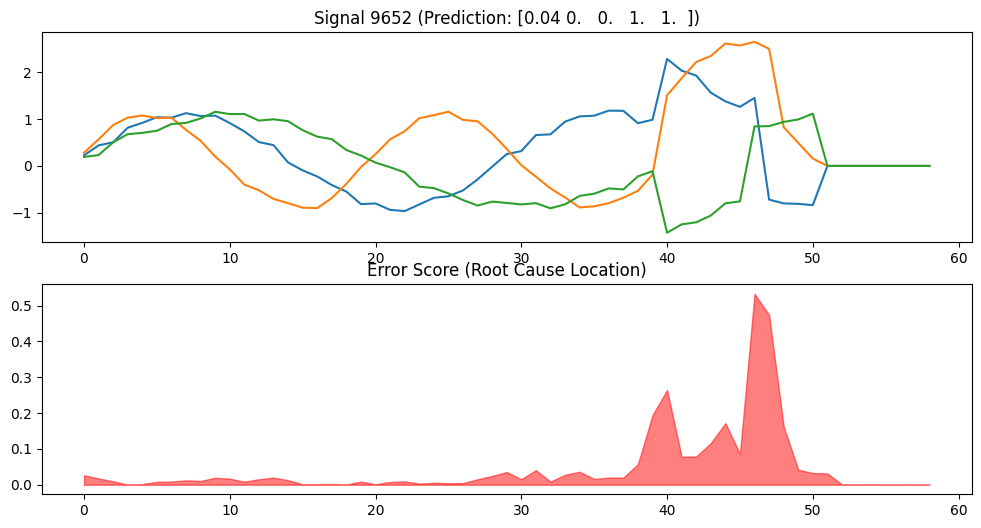


Analyzing: Candy Index 6633
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


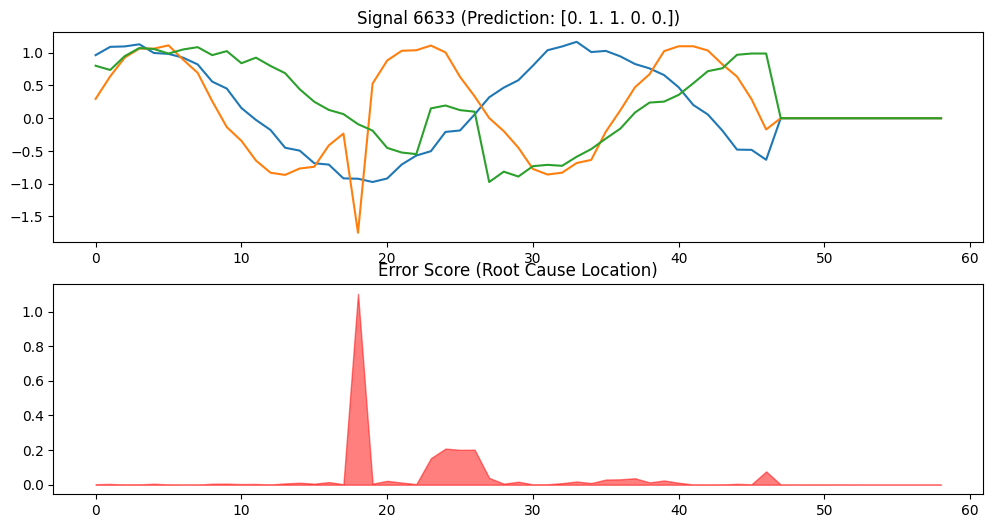


Analyzing: Candy Index 2866
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


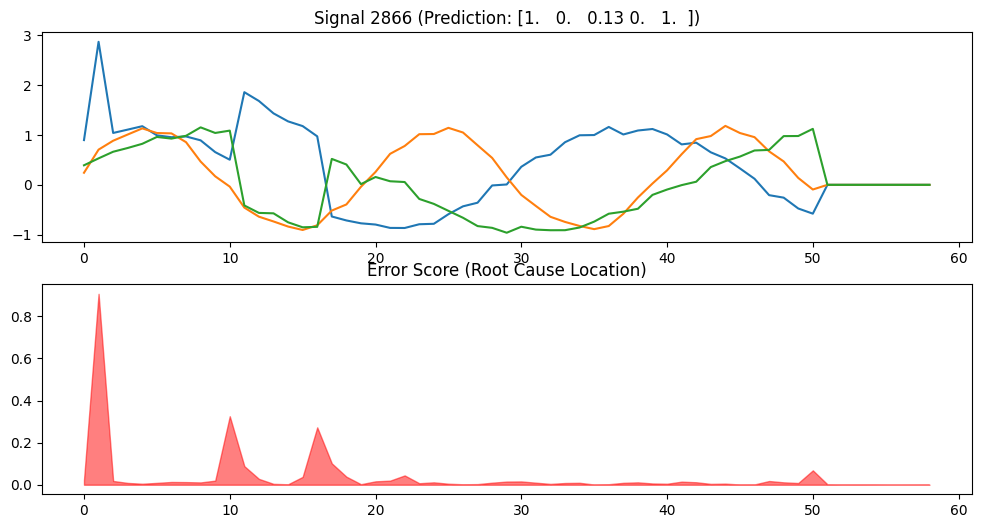


Analyzing: Candy Index 8676
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


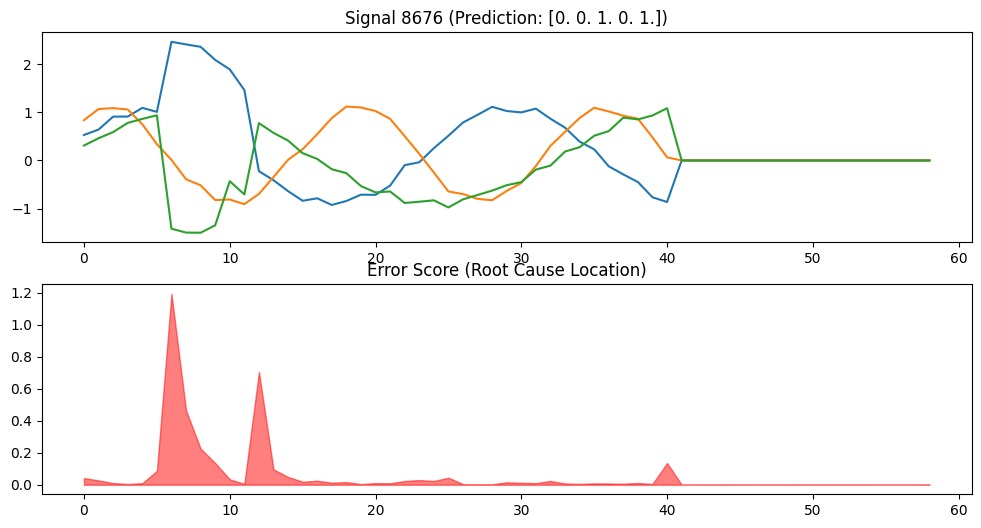


Analyzing: Candy Index 7234
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


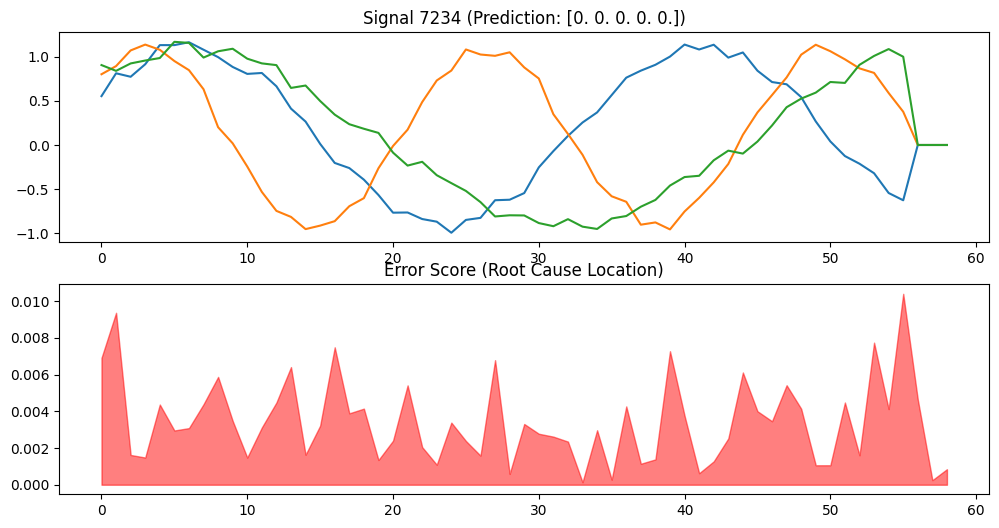

In [ ]:
# 2. Visualize 20 different random candies using a loop
# Each time you run it, different candies and different plots will appear
random_indices = np.random.choice(len(X_test), 20, replace=False)

for i in random_indices:
    print(f"\nAnalyzing: Candy Index {i}")
    visualize_results(i)


Those pictures are showing how the neural networks are detecting the default in the sensors captation. In case of no default detected the error score looks really noïsy  but in reality the scale is really small so it does not mean that it detect a default.  
Default 1 and 2 are detect with an higher error score than the default 3,4 and 5 however the detection of those default are still really effecient.